In [1]:
import ast
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
df=pd.read_csv('data_jobs.csv')
df['job_posted_date']=pd.to_datetime(df['job_posted_date'])
df['job_skills']=df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [2]:
df_India=df[(df['job_country']=='India')].dropna(subset=['salary_year_avg'])

In [4]:
job_titles=df_India['job_title_short'].value_counts().index[:6].tolist()
job_titles

['Data Engineer',
 'Data Analyst',
 'Data Scientist',
 'Machine Learning Engineer',
 'Senior Data Engineer',
 'Software Engineer']

In [5]:
df_India_top6=df_India[df_India['job_title_short'].isin(job_titles)]

In [11]:
job_orders=df_India_top6.groupby('job_title_short')['salary_year_avg'].median().sort_values(ascending=False).index

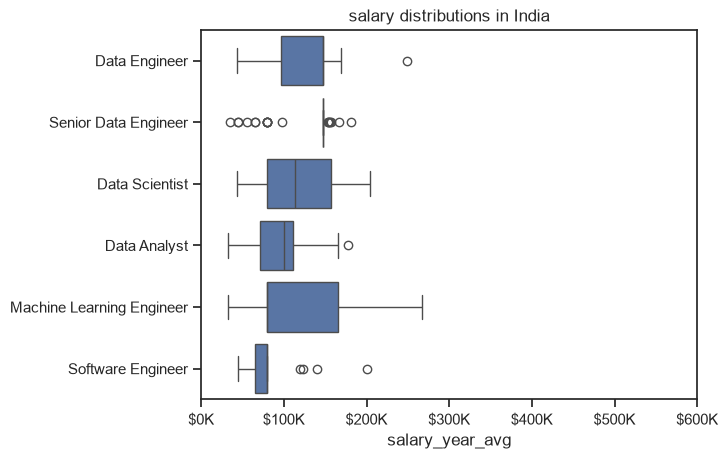

In [15]:
sns.boxplot(data=df_India_top6,x='salary_year_avg',y='job_title_short',order=job_orders)
sns.set_theme(style='ticks')

plt.title("salary distributions in India")
plt.ylabel('')
plt.xlim(0,600000)
ticks_x=plt.FuncFormatter(lambda y, pos:f'${int (y/1000)}K')
plt.gca().xaxis.set_major_formatter(ticks_x)
plt.show()